# Computer Exercise 15.34 — Problem 1
## Cramér 대 KL, 프로토콜 v2 아래에서의 최종 재판정 — 순위는 손실의 성질인가 $\eta$ 의 함수인가

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing*, 7th ed. — 확장 사례연구 Ch 15
> **단원**: §15.34 Sequential Decision Making — Distributional Losses, Re-adjudicated
> **선행**: §15.26 (Day 93) · §15.27 (Day 94) · §15.28 (Day 95) · §15.29 (Day 96) · §15.33 (Day 100)
> **풀이 일자**: Day 101 · **언어**: Python (NumPy / pandas / Matplotlib / SciPy)

Ch 15 에 남은 **마지막 미결**이다. 네 Day 가 같은 질문에 서로 다른 답을 냈다.

| 출처 | 설정 | 보고된 순위 | $n$ |
|---|---|---|---|
| §15.26 P2 (Day 93) | tabular per-$(s,a)$ $K$-원자 head | **Cramér ≫ KL** ("완파") | 3 |
| §15.27 P2 (Day 94) | neural (공유 트렁크 $H{=}16$) head | **KL ≫ Cramér** ("완전 역전") | 3 |
| §15.28 P2 (Day 95) | wider trunk $H \in \{32,64\}$ | 판정불능 (near-uniform 수렴) | 3 |
| §15.29 P2 (Day 96) | harder chain $p_{\text{train}}{=}0.20$ | 재출현 시도 | 3 |

Day 94 는 이 모순을 **"head 아키텍처 artifact"** 로 설명했다. 그러나 그 설명은 $n=3$ 에서
나왔고, 프로토콜 v2 (Day 100 §15.33) 의 어떤 요건도 만족하지 않는다 — 사전 명시 없음,
통제군 없음, 다중검정 보정 없음, A/A 점검 없음, **층 0 귀무 검증 없음**.

오늘 그것을 $n=40$ 에서 다시 판정한다.

## 1. 문제 (원문)

> **Computer Exercise 15.34.1.** Exercises 15.26–15.29 reported *contradictory* orderings of the
> Cramér (CDF-distance) and KL (cross-entropy) losses for a categorical distributional
> $Q$-learner on a five-state chain MDP: the tabular head favoured Cramér, the neural head
> favoured KL, and the wide-trunk head separated neither. Each conclusion rested on three seeds
> and a *single shared* learning rate $\eta = 0.02$.
>
> Re-adjudicate the comparison under the pre-registered protocol of Exercise 15.33.
> (a) Measure the mean gradient magnitude $\mathbb{E}\lVert \partial \mathcal{L}/\partial \ell \rVert$
> that each loss delivers to the logits, and state what a *shared* $\eta$ therefore compares.
> (b) On a **disjoint tuning pool** of seeds, select $\eta^\star$ separately for each loss.
> (c) On a fresh pool of $n \ge 30$ seeds, test the pre-registered family: the ordering at the
> inherited $\eta = 0.02$, the ordering at a large $\eta$, their interaction, and the ordering at
> each loss's own $\eta^\star$. Use a sign-flip permutation test with Holm correction, at least two
> control arms, an A/A check, and a **stratum-0 verification that the null used for calibration is
> in fact a null**.
> (d) Report whether the Day 93 / Day 94 disagreement can be manufactured *without* changing the
> head architecture at all.

### 한국어 풀이용 정리

1. **기울기 크기 측정** — 두 손실이 logit 에 주는 $\lVert \mathrm{d}\ell \rVert$ 의 비를 잰다.
   비가 1 이 아니면 **공유 $\eta$ 는 손실이 아니라 유효 보폭을 비교**하는 것이다.
2. **$\eta^\star$ 를 분리된 튜닝 풀에서 선택** — 선택과 판정을 같은 자료로 하면 Day 100 P2 의
   승자의 저주가 그대로 재발한다. 튜닝 시드 (101101–101110) 와 판정 시드 (101001–101040) 를
   **비중첩**으로 둔다.
3. **사전 명시 가족 $m=4$** — $c_1$ (낮은 $\eta$), $c_2$ (높은 $\eta$), $c_3 = c_1 - c_2$ (교호작용),
   $c_4$ (각자의 $\eta^\star$ 에서의 공정 비교).
4. **통제군 3 개** — `inert` (같은 손실·같은 시드 → 비트 일치), A/A (같은 손실·다른 스트림),
   양성 통제 (학습 대 미학습 → 척도에 검정력이 있는가).
5. **층 0 귀무 검증** — A/A 귀무를 **재무작위화** 로 구성하고, 구성 불변성을 확인한다.
   Day 100 P1 이 폐기한 "고정 차 벡터의 부분표본" 방식은 쓰지 않는다.

## 2. 수학적 배경

### 2.1 범주형 분포 $Q$ 와 두 손실

원자 격자 $z_1 < \dots < z_K$ 위의 확률 $\hat p_\theta(s,a) = \mathrm{softmax}(\ell_\theta(s,a))$ 로
수익 분포를 표현한다. Bellman 목표는 $\mathcal{T}z_k = r + \gamma z_k$ 를 격자에 사영해서 얻는다:

$$m_j \;=\; \sum_{k=1}^{K} \Bigl[1 - \frac{|[\mathcal{T}z_k]_{z_1}^{z_K} - z_j|}{\Delta z}\Bigr]_0^1 \, p_{k}(s', a^\star), \qquad a^\star = \arg\max_a \, z^\top \hat p(s',a).$$

두 손실의 logit 기울기는 닫힌 형태를 갖는다. **KL** (교차엔트로피 $-\sum_j m_j \log \hat p_j$) 은

$$\boxed{\;\frac{\partial \mathcal{L}_{\mathrm{KL}}}{\partial \ell} \;=\; \hat p - m\;}$$

이고, **Cramér** ($\ell_2$ CDF 거리 $\tfrac12\sum_j (\hat F_j - F^m_j)^2$, $\hat F_j = \sum_{k\le j}\hat p_k$) 는
softmax Jacobian $\partial \hat p / \partial \ell = \mathrm{diag}(\hat p) - \hat p \hat p^\top$ 를 통과시켜

$$\boxed{\;\frac{\partial \mathcal{L}_{\mathrm{Cr}}}{\partial \ell_j} \;=\; 2\,\hat p_j \Bigl( S_j - \sum_k \hat p_k S_k \Bigr), \qquad S_j = \sum_{i \ge j} (\hat F_i - F^m_i).\;}$$

### 2.2 두 기울기는 같은 축척을 갖지 않는다

KL 기울기는 $\lVert \hat p - m\rVert_1 \le 2$ 로 **균일 유계**다. Cramér 기울기의 $S_j$ 는 CDF 차의
**누적합**이므로 최악의 경우 $O(K)$ 로 커진다. 따라서 어떤 상수 $\kappa$ 에 대해

$$\mathbb{E}\bigl\lVert \partial\mathcal{L}_{\mathrm{Cr}}/\partial\ell \bigr\rVert \;=\; \kappa \cdot
\mathbb{E}\bigl\lVert \partial\mathcal{L}_{\mathrm{KL}}/\partial\ell \bigr\rVert, \qquad \kappa \ne 1,$$

이고, 공유 $\eta$ 로 두 손실을 학습시키면 실제로 비교되는 것은 손실 함수가 아니라
$(\eta, \kappa\eta)$ **두 보폭**이다. 학습 곡선 $R(\eta)$ 가 단봉이고 정점이 $\eta_0$ 라면,
$\eta < \eta_0/\kappa$ 구간에서는 큰 기울기 쪽이 이기고 $\eta > \eta_0$ 구간에서는 진다 —
**순위의 부호가 $\eta$ 만으로 뒤집힌다.** 이것이 오늘의 귀무가설이다.

$$H_0^{\text{arch}}: \text{순위는 head 아키텍처의 함수다}
\qquad \text{대}\qquad
H_1^{\eta}: \text{순위는 } \eta \text{ 의 함수이며 아키텍처는 부수적이다.}$$

### 2.3 판정 규칙 (프로토콜 v2, Day 100 P1 에서 채택)

짝지은 차 $d_i = R^{\mathrm{Cr}}_i - R^{\mathrm{KL}}_i$ 에 대해 **부호뒤집기 순열검정**

$$p = \frac{1 + \#\{b : |\overline{\varepsilon^{(b)} \odot d}| \ge |\bar d|\}}{B+1},
\qquad \varepsilon^{(b)}_i \overset{\text{iid}}{\sim} \mathrm{Unif}\{-1,+1\},$$

를 쓴다. $d_i$ 의 분포가 0 에 대해 대칭이라는 귀무 아래 **유한표본 정확**하다 (Day 100 P1 이
백분위 bootstrap CI 0.126 · $\mathrm{BC}_a$ 0.201 대 sign-flip 0.061 을 실측하고 채택한 이유).
가족 $m=4$ 에는 Holm–Bonferroni 를, 구간에는 **검정 반전 CI** 를 쓴다.

$$\text{CI}_{1-\alpha} = \{\delta : p_{\text{sign-flip}}(d - \delta) > \alpha\}.$$

### 2.4 필요 표본 크기

$n^\star \approx \bigl(2.8\, s_d / |\bar d|\bigr)^2$ (Cohen, $\alpha{=}0.05$, power $0.8$). 보고된 $n^\star$ 가
실제 $n$ 을 크게 넘으면 그 비교는 **판정불능**이며, "유의하지 않다" 와 "차이가 없다" 를
구별해서 적는다.

## 3. 풀이 흐름

1. **공통 설정** — 5-상태 chain MDP, tabular / neural 범주형 head, 두 손실의 logit 기울기,
   판정 규칙 (sign-flip · Holm · 검정 반전 CI · $n^\star$ · Wilson) 을 정의한다.
2. **사전 명시** — 자료 생성 전에 가설·가족·규칙·$n$·중지 규칙을 못박고 출력한다.
3. **[1] 기울기 축척 측정** — 학습 초기 400 스텝에서 $\lVert \mathrm{d}\ell \rVert$ 을 두 손실·두 head
   에서 재고 $\kappa$ 를 추정한다.
4. **[2] 튜닝 풀** — 판정 시드와 **비중첩** 인 16 개 시드에서 $\eta \in \{0.02, 0.05, 0.15, 0.4, 1.0\}$
   격자를 훑어 $\eta^\star_{\mathrm{Cr}}, \eta^\star_{\mathrm{KL}}$ 를 손실별로 고른다.
5. **[3] 판정 풀** — 신규 40 시드에서 사전 명시된 네 조건을 학습·배포한다.
6. **[4] 통제군** — `inert` (비트 일치 assert) · A/A · 양성 통제 세 개를 돌린다.
7. **[5] 층 0 귀무 검증** — A/A 귀무를 재무작위화로 구성하고, 4 개 배포 스트림의
   $\binom{4}{2}=6$ 가지 구성 전부에서 1 종 오류가 안정한지 확인한다.
8. **[6] 판정** — 가족 $m=4$ 에 sign-flip + Holm, 검정 반전 CI, $n^\star$.
9. **[7]–[8] 시각화와 요약** — $\eta$ 곡선과 부호 뒤집힘 지점, forest plot, 판정표.

In [1]:
# ── 공통 설정 ─────────────────────────────────────────────────────────────
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass
import numpy as np, pandas as pd, time
import matplotlib.pyplot as plt
from scipy.stats import norm

pd.set_option("display.float_format", lambda v: f"{v:.4f}")
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.3, "figure.autolayout": True})

# ── 벤치마크: 5-상태 chain MDP (§15.26–§15.29 계열 재구성) ────────────────
NS, NA, L, GAMMA = 5, 2, 20, 0.95

def env_step(s, a, p_slip, rng):
    if rng.random() < p_slip: a = 1 - a
    ns = max(0, min(NS - 1, s + (1 if a == 1 else -1)))
    return ns, (1.0 if ns == NS - 1 else 0.0)

def onehot(s):
    v = np.zeros(NS); v[s] = 1.0; return v

def softmax(z):
    z = z - z.max(); e = np.exp(z); return e / e.sum()

def cat_project(r, p_next, z, K):
    """범주형 Bellman 사영 (C51 의 표준 사영)."""
    Tz = np.clip(r + GAMMA * z, z[0], z[-1])
    b  = (Tz - z[0]) / (z[-1] - z[0] + 1e-9) * (K - 1)
    lo = np.floor(b).astype(int); hi = np.ceil(b).astype(int)
    m  = np.zeros(K)
    np.add.at(m, lo, p_next * (hi - b))
    np.add.at(m, hi, p_next * (b - lo))
    eq = (lo == hi)
    if eq.any():
        m[lo[eq]] = 0.0
        np.add.at(m, lo[eq], p_next[eq])
    return m

def dlogits_of(p_hat, m, loss):
    """§2.1 의 두 닫힌 형태.  KL 은 유계, Cramer 는 CDF 차의 누적합."""
    if loss == "KL":
        return p_hat - m
    S = np.cumsum((np.cumsum(p_hat) - np.cumsum(m))[::-1])[::-1]
    return 2.0 * p_hat * (S - float(p_hat @ S))

class TabHead:                      # Day 93 (§15.26) 계열
    kind = "tabular"
    def __init__(self, K, rng, z_max=1.0):
        self.K = K; self.z = np.linspace(0.0, z_max, K)
        self.P = rng.normal(0, 0.3, size=(NS, NA, K))
    def probs(self, s, a): return softmax(self.P[s, a])
    def qvalues(self, s):  return np.array([float(self.z @ softmax(self.P[s, a])) for a in range(NA)])
    def grad(self, s, a, r, sp, loss):
        pn = self.probs(sp, int(np.argmax(self.qvalues(sp))))
        return dlogits_of(self.probs(s, a), cat_project(r, pn, self.z, self.K), loss)
    def update(self, s, a, r, sp, loss, eta):
        self.P[s, a] -= eta * self.grad(s, a, r, sp, loss)
    def entropy(self):
        return float(np.mean([-(p*np.log(p+1e-12)).sum()
                              for s in range(NS) for p in (softmax(self.P[s,a]) for a in range(NA))]))

class NeuHead:                      # Day 94 (§15.27) 계열
    kind = "neural"
    def __init__(self, K, rng, H=16, z_max=1.0):
        self.K, self.H = K, H; self.z = np.linspace(0.0, z_max, K)
        self.W1 = rng.normal(0, 0.3, size=(H, NS))
        self.W2 = rng.normal(0, 0.3, size=(NA, K, H))
    def _h(self, s):
        x = onehot(s); return x, np.tanh(self.W1 @ x)
    def probs(self, s, a): return softmax(self.W2[a] @ self._h(s)[1])
    def qvalues(self, s):
        h = self._h(s)[1]
        return np.array([float(self.z @ softmax(self.W2[a] @ h)) for a in range(NA)])
    def grad(self, s, a, r, sp, loss):
        pn = self.probs(sp, int(np.argmax(self.qvalues(sp))))
        return dlogits_of(self.probs(s, a), cat_project(r, pn, self.z, self.K), loss)
    def update(self, s, a, r, sp, loss, eta):
        x, h = self._h(s)
        dl = self.grad(s, a, r, sp, loss)
        gh = self.W2[a].T @ dl
        self.W2[a] -= eta * np.outer(dl, h)
        self.W1    -= eta * np.outer(gh * (1 - h ** 2), x)
    def entropy(self):
        return float(np.mean([-(p*np.log(p+1e-12)).sum()
                              for s in range(NS) for p in (self.probs(s,a) for a in range(NA))]))

HEADS = {"tabular": TabHead, "neural": NeuHead}
T_FIXED, P_TRAIN, EPS_G, K_MAIN = 1200, 0.20, 0.20, 21
SLIPS = (0.05, 0.10, 0.15, 0.20, 0.25)
ALPHA, B_MAIN = 0.05, 20_000

def train(seed, head, loss, eta, K=K_MAIN, T=T_FIXED, probe=0):
    """초기 가중치와 환경 스트림은 (seed, head, K) 에만 의존 -> 두 손실이 완전히 짝지어진다."""
    hd  = HEADS[head](K, np.random.default_rng(seed))
    rng = np.random.default_rng(seed + 777); g = []
    for t in range(T):
        s = int(rng.integers(0, NS))
        a = int(rng.integers(0, NA)) if rng.random() < EPS_G else int(np.argmax(hd.qvalues(s)))
        sp, r = env_step(s, a, P_TRAIN, rng)
        if t < probe: g.append(float(np.linalg.norm(hd.grad(s, a, r, sp, loss))))
        hd.update(s, a, r, sp, loss, eta)
    hd.gnorm = float(np.mean(g)) if g else np.nan
    return hd

def deploy(hd, p_d, stream, n_ep=40, tail=8):
    rng = np.random.default_rng(stream); tot = 0.0
    for _ in range(n_ep):
        s = int(rng.integers(0, NS)); rs = []
        for _ in range(L):
            s, r = env_step(s, int(np.argmax(hd.qvalues(s))), p_d, rng); rs.append(r)
        tot += float(np.mean(rs[-tail:]))
    return tot / n_ep

def cross_slip(hd, stream):
    """5 개 배포 슬립에 대한 tail-8 평균 (§15.29 P2 와 같은 척도)."""
    return float(np.mean([deploy(hd, p, stream + 13 * i) for i, p in enumerate(SLIPS)]))

# ── 판정 규칙 (프로토콜 v2) ───────────────────────────────────────────────
def signflip_p(d, B=B_MAIN, seed=1, rng=None):
    rng = np.random.default_rng(seed) if rng is None else rng
    d = np.asarray(d, float); obs = abs(d.mean())
    null = np.abs((rng.choice([-1.0, 1.0], size=(B, len(d))) * d).mean(axis=1))
    return float((1 + (null >= obs - 1e-15).sum()) / (B + 1))

def holm(pvals, alpha=ALPHA):
    p = np.asarray(pvals, float); m = len(p); order = np.argsort(p)
    adj = np.empty(m); run = 0.0
    for k, i in enumerate(order):
        run = max(run, (m - k) * p[i]); adj[i] = min(1.0, run)
    return adj, adj <= alpha

_CI_CACHE = {}
def invert_ci(d, B=3000, seed=7, alpha=ALPHA, lo=-2.0, hi=2.0, it=22):
    """검정 반전 CI: sign-flip 이 기각하지 않는 delta 의 집합 (1 차 규칙과 정합)."""
    d = np.asarray(d, float); key = (d.tobytes(), B, seed)
    if key in _CI_CACHE: return _CI_CACHE[key]
    c = d.mean()
    def ok(delta): return signflip_p(d - delta, B=B, seed=seed) > alpha
    if not ok(c):
        _CI_CACHE[key] = (np.nan, np.nan); return _CI_CACHE[key]
    a, b = c, c + hi
    for _ in range(it):
        mid = 0.5 * (a + b); a, b = (mid, b) if ok(mid) else (a, mid)
    up = 0.5 * (a + b)
    a, b = c + lo, c
    for _ in range(it):
        mid = 0.5 * (a + b); a, b = (a, mid) if ok(mid) else (mid, b)
    _CI_CACHE[key] = (0.5 * (a + b), up)
    return _CI_CACHE[key]

def n_star(d, c=2.8):
    d = np.asarray(d, float); m, s = abs(d.mean()), d.std(ddof=1)
    return int(np.ceil((c * s / m) ** 2)) if m > 1e-12 else np.inf

def wilson(k, n, z=1.96):
    if n == 0: return (np.nan, np.nan)
    p = k / n; den = 1 + z*z/n; ctr = (p + z*z/(2*n)) / den
    hw = z * np.sqrt(p*(1-p)/n + z*z/(4*n*n)) / den
    return (max(0.0, ctr-hw), min(1.0, ctr+hw))

print(f"chain MDP  states={NS} actions={NA} ep_len={L} gamma={GAMMA} p_train={P_TRAIN}")
print(f"범주형 head  tabular / neural(H=16)   K={K_MAIN}   T={T_FIXED}   배포 슬립 {SLIPS}")
print("판정 규칙: sign-flip 순열검정 + Holm + 검정 반전 CI  [프로토콜 v2]")

chain MDP  states=5 actions=2 ep_len=20 gamma=0.95 p_train=0.2
범주형 head  tabular / neural(H=16)   K=21   T=1200   배포 슬립 (0.05, 0.1, 0.15, 0.2, 0.25)
판정 규칙: sign-flip 순열검정 + Holm + 검정 반전 CI  [프로토콜 v2]


In [2]:
# ══════════════════════════════════════════════════════════════════════════
# [사전 명시 — PRE-REGISTRATION]   자료 생성 전에 실행
# ══════════════════════════════════════════════════════════════════════════
PRE = {
 "질문": "Cramer 대 KL 의 순위는 손실의 성질인가, 학습률 eta 의 함수인가",
 "선행 주장": "Day 93 = tabular 에서 Cramer 승 / Day 94 = neural 에서 KL 승 (둘 다 n=3, eta=0.02 공유)",
 "1차 가족 (m=4, 순서 고정)": [
   "c1 = R(Cramer) - R(KL)  @ neural, eta=0.02   <- Day 93/94 가 물려준 셀",
   "c2 = R(Cramer) - R(KL)  @ neural, eta=1.00   <- 큰 보폭",
   "c3 = c1 - c2                                  <- 교호작용: 순위가 eta 에 의존하는가",
   "c4 = R(Cramer @ eta*_Cr) - R(KL @ eta*_KL)    <- 각자의 최적 보폭에서의 공정 비교",
 ],
 "1차 판정 규칙": "부호뒤집기 순열검정 B=20000, alpha=0.05, Holm(m=4), 검정 반전 CI",
 "표본 크기": "n=40 신규 독립 시드 101001-101040 (v2 최소 30 초과)",
 "eta* 선택": "비중첩 튜닝 풀 101101-101110 (10 시드) 에서만 선택. 판정 풀은 선택에 관여 안 함",
 "통제군 (3)": ["inert : KL 대 KL, 같은 시드 -> 비트 일치 (차가 정확히 0)",
                "A/A   : KL 대 KL, 다른 학습 스트림 -> 유의하면 안 됨",
                "양성  : KL(학습) 대 미학습 head -> 강하게 양수여야 함 (검정력 존재 확인)"],
 "층 0 귀무 검증": "A/A 귀무는 재무작위화로 구성. 4 개 배포 스트림의 6 가지 쌍 구성 전부에서 1종오류 확인",
 "사전 예측": "H1 이 옳다면 c1 > 0, c2 <= 0 (부호 뒤집힘), c3 > 0, c4 ~ 0 (판정불능)",
 "중지 규칙": "n=40 을 다 쓰고 한 번만 판정한다. 중간 들여다보기 없음.",
}
print("═"*78); print("PRE-REGISTRATION   (Day 101 §15.34 P1)"); print("═"*78)
for k, v in PRE.items():
    if isinstance(v, list): print(f"{k}:"); [print(f"    - {x}") for x in v]
    else: print(f"{k}: {v}")
print("═"*78)

SEEDS_MAIN = list(range(101001, 101041)); N1 = len(SEEDS_MAIN)
SEEDS_TUNE = list(range(101101, 101111)); NT = len(SEEDS_TUNE)
ETA_GRID   = [0.02, 0.05, 0.15, 0.40, 1.00]
ETA_LOW, ETA_HIGH = 0.02, 1.00
STREAM0 = 910_000
assert not set(SEEDS_MAIN) & set(SEEDS_TUNE), "튜닝 풀과 판정 풀은 비중첩이어야 한다"
print(f"판정 풀 n={N1} (101001-101040) · 튜닝 풀 n={NT} (101101-101110) · 비중첩 확인 ✓")

══════════════════════════════════════════════════════════════════════════════
PRE-REGISTRATION   (Day 101 §15.34 P1)
══════════════════════════════════════════════════════════════════════════════
질문: Cramer 대 KL 의 순위는 손실의 성질인가, 학습률 eta 의 함수인가
선행 주장: Day 93 = tabular 에서 Cramer 승 / Day 94 = neural 에서 KL 승 (둘 다 n=3, eta=0.02 공유)
1차 가족 (m=4, 순서 고정):
    - c1 = R(Cramer) - R(KL)  @ neural, eta=0.02   <- Day 93/94 가 물려준 셀
    - c2 = R(Cramer) - R(KL)  @ neural, eta=1.00   <- 큰 보폭
    - c3 = c1 - c2                                  <- 교호작용: 순위가 eta 에 의존하는가
    - c4 = R(Cramer @ eta*_Cr) - R(KL @ eta*_KL)    <- 각자의 최적 보폭에서의 공정 비교
1차 판정 규칙: 부호뒤집기 순열검정 B=20000, alpha=0.05, Holm(m=4), 검정 반전 CI
표본 크기: n=40 신규 독립 시드 101001-101040 (v2 최소 30 초과)
eta* 선택: 비중첩 튜닝 풀 101101-101110 (10 시드) 에서만 선택. 판정 풀은 선택에 관여 안 함
통제군 (3):
    - inert : KL 대 KL, 같은 시드 -> 비트 일치 (차가 정확히 0)
    - A/A   : KL 대 KL, 다른 학습 스트림 -> 유의하면 안 됨
    - 양성  : KL(학습) 대 미학습 head -> 강하게 양수여야 함 (검정력 존재 확인)
층 0 귀무 검증: A/A 귀무는 재무작위화로 구성. 4 개 

In [3]:
# ── [1] 기울기 축척 kappa 측정 (§2.2) ─────────────────────────────────────
t0 = time.time(); rows = []
for head in ["tabular", "neural"]:
    g = {}
    for loss in ["Cramer", "KL"]:
        g[loss] = np.mean([train(s, head, loss, 0.02, T=300, probe=200).gnorm
                           for s in SEEDS_TUNE[:4]])
    rows.append({"head": head, "||dl|| Cramer": g["Cramer"], "||dl|| KL": g["KL"],
                 "kappa": g["Cramer"] / g["KL"]})
grad_df = pd.DataFrame(rows)
KAPPA = float(grad_df["kappa"].mean())
print(f"기울기 축척 측정  ({time.time()-t0:.1f} s)")
print(grad_df.to_string(index=False))
print(f"\n평균 kappa = {KAPPA:.3f}  ->  공유 eta 는 두 손실이 아니라 보폭 (eta, {KAPPA:.2f}*eta) 를 비교한다")

기울기 축척 측정  (0.5 s)
   head  ||dl|| Cramer  ||dl|| KL  kappa
tabular         0.3766     0.2777 1.3560
 neural         0.3684     0.2483 1.4835

평균 kappa = 1.420  ->  공유 eta 는 두 손실이 아니라 보폭 (eta, 1.42*eta) 를 비교한다


In [4]:
# ── [2] 튜닝 풀 (판정 풀과 비중첩) 에서 eta* 선택 ────────────────────────
t0 = time.time(); tune = []
for head in ["tabular", "neural"]:
    for loss in ["Cramer", "KL"]:
        for eta in ETA_GRID:
            R = np.array([cross_slip(train(s, head, loss, eta), STREAM0 + 31*i)
                          for i, s in enumerate(SEEDS_TUNE)])
            tune.append({"head": head, "loss": loss, "eta": eta,
                         "R_mean": R.mean(), "R_sd": R.std(ddof=1)})
tune_df = pd.DataFrame(tune)
piv = tune_df.pivot_table(index=["head", "loss"], columns="eta", values="R_mean")
ETA_STAR = {}
for head in ["tabular", "neural"]:
    for loss in ["Cramer", "KL"]:
        sub = tune_df[(tune_df["head"] == head) & (tune_df.loss == loss)]
        ETA_STAR[(head, loss)] = float(sub.loc[sub.R_mean.idxmax(), "eta"])
print(f"튜닝 풀 {NT} 시드 x 2 head x 2 loss x {len(ETA_GRID)} eta  ({time.time()-t0:.1f} s)\n")
print(piv.to_string())
print("\neta* (튜닝 풀에서만 선택):")
for k, v in ETA_STAR.items(): print(f"    {k[0]:8s} {k[1]:7s} -> eta* = {v}")
ETA_C, ETA_K = ETA_STAR[("neural", "Cramer")], ETA_STAR[("neural", "KL")]

튜닝 풀 10 시드 x 2 head x 2 loss x 5 eta  (29.0 s)

eta             0.0200  0.0500  0.1500  0.4000  1.0000
head    loss                                          
neural  Cramer  0.5577  0.7046  0.7831  0.8215  0.7398
        KL      0.2974  0.5503  0.8159  0.8215  0.8181
tabular Cramer  0.4098  0.5431  0.6714  0.8215  0.8215
        KL      0.3422  0.3674  0.5874  0.7084  0.7836

eta* (튜닝 풀에서만 선택):
    tabular  Cramer  -> eta* = 0.4
    tabular  KL      -> eta* = 1.0
    neural   Cramer  -> eta* = 0.4
    neural   KL      -> eta* = 0.4


In [5]:
# ── [3] 판정 풀 40 시드 학습·배포 ─────────────────────────────────────────
t0 = time.time()
NEED = sorted({("neural", "Cramer", ETA_LOW), ("neural", "KL", ETA_LOW),
               ("neural", "Cramer", ETA_HIGH), ("neural", "KL", ETA_HIGH),
               ("neural", "Cramer", ETA_C),   ("neural", "KL", ETA_K),
               ("tabular", "Cramer", ETA_LOW), ("tabular", "KL", ETA_LOW)})
R = {}
for (head, loss, eta) in NEED:
    R[(head, loss, eta)] = np.array(
        [cross_slip(train(s, head, loss, eta), STREAM0 + 31*i) for i, s in enumerate(SEEDS_MAIN)])
print(f"판정 풀 {N1} 시드 x {len(NEED)} 조건  ({time.time()-t0:.1f} s)")

c1 = R[("neural","Cramer",ETA_LOW)]  - R[("neural","KL",ETA_LOW)]
c2 = R[("neural","Cramer",ETA_HIGH)] - R[("neural","KL",ETA_HIGH)]
c3 = c1 - c2
c4 = R[("neural","Cramer",ETA_C)]    - R[("neural","KL",ETA_K)]
t1 = R[("tabular","Cramer",ETA_LOW)] - R[("tabular","KL",ETA_LOW)]   # head 축 (2차)
summ = pd.DataFrame([
    {"조건": "neural eta=0.02",       "Cramer": R[("neural","Cramer",ETA_LOW)].mean(),
     "KL": R[("neural","KL",ETA_LOW)].mean(),  "차": c1.mean()},
    {"조건": "neural eta=1.00",       "Cramer": R[("neural","Cramer",ETA_HIGH)].mean(),
     "KL": R[("neural","KL",ETA_HIGH)].mean(), "차": c2.mean()},
    {"조건": f"neural eta* ({ETA_C}/{ETA_K})", "Cramer": R[("neural","Cramer",ETA_C)].mean(),
     "KL": R[("neural","KL",ETA_K)].mean(),    "차": c4.mean()},
    {"조건": "tabular eta=0.02",      "Cramer": R[("tabular","Cramer",ETA_LOW)].mean(),
     "KL": R[("tabular","KL",ETA_LOW)].mean(), "차": t1.mean()},
])
def pol(hd): return tuple(int(np.argmax(hd.qvalues(s_))) for s_ in range(NS))
OPT = tuple([1]*NS)
opt_rate = {}
for (head, loss, eta) in [("neural","Cramer",ETA_LOW), ("neural","KL",ETA_LOW),
                          ("neural","Cramer",ETA_C),   ("neural","KL",ETA_K)]:
    opt_rate[(loss, eta)] = float(np.mean([pol(train(s_, head, loss, eta)) == OPT
                                           for s_ in SEEDS_MAIN]))
print(); print(summ.to_string(index=False))
print("\n최적 정책 (1,1,1,1,1) 도달률 — neural:")
for (loss, eta), v in opt_rate.items():
    print(f"    {loss:7s} eta={eta:<5} : {v:.3f}  ({int(v*N1)}/{N1} 시드)")

판정 풀 40 시드 x 8 조건  (50.7 s)



                   조건  Cramer     KL       차
      neural eta=0.02  0.6535 0.3345  0.3190
      neural eta=1.00  0.7125 0.8105 -0.0980
neural eta* (0.4/0.4)  0.8161 0.8161  0.0000
     tabular eta=0.02  0.2182 0.1848  0.0333

최적 정책 (1,1,1,1,1) 도달률 — neural:
    Cramer  eta=0.02  : 0.425  (17/40 시드)
    KL      eta=0.02  : 0.075  (3/40 시드)
    Cramer  eta=0.4   : 1.000  (40/40 시드)
    KL      eta=0.4   : 1.000  (40/40 시드)


In [6]:
# ── [4] 통제군 3 개 ───────────────────────────────────────────────────────
t0 = time.time()
# (i) inert — 같은 손실·같은 시드·같은 eta 를 두 번:  차가 정확히 0 이어야 한다
inert = np.array([cross_slip(train(s, "neural", "KL", ETA_LOW), STREAM0 + 31*i) -
                  cross_slip(train(s, "neural", "KL", ETA_LOW), STREAM0 + 31*i)
                  for i, s in enumerate(SEEDS_MAIN[:8])])
assert np.all(inert == 0.0), "결정성 위반 — 같은 입력이 다른 출력을 냈다"
print(f"[통제 1] inert  : max|diff| = {np.abs(inert).max():.1e}  (비트 일치 ✓)")

# (ii) A/A — 같은 손실, 시드만 다른 두 풀
AA_SEEDS = list(range(101301, 101341))
aa_a = np.array([cross_slip(train(s, "neural", "KL", ETA_LOW), STREAM0 + 31*i)
                 for i, s in enumerate(AA_SEEDS)])
aa_b = np.array([cross_slip(train(s + 500, "neural", "KL", ETA_LOW), STREAM0 + 31*i)
                 for i, s in enumerate(AA_SEEDS)])
d_aa = aa_a - aa_b
p_aa = signflip_p(d_aa, seed=11)
print(f"[통제 2] A/A    : d = {d_aa.mean():+.4f}, sign-flip p = {p_aa:.3f} "
      f"({'통과 — 비유의' if p_aa > ALPHA else '경보 — 유의!'})")

# (iii) 양성 통제 — 학습된 KL 대 미학습 head (척도에 검정력이 있는가)
untr = np.array([cross_slip(train(s, "neural", "KL", ETA_LOW, T=0), STREAM0 + 31*i)
                 for i, s in enumerate(SEEDS_MAIN)])
d_pos = R[("neural","KL",ETA_LOW)] - untr
p_pos = signflip_p(d_pos, seed=12)
print(f"[통제 3] 양성   : d = {d_pos.mean():+.4f}, sign-flip p = {p_pos:.4f} "
      f"({'통과 — 검정력 존재' if p_pos <= ALPHA else '경보 — 척도 무력!'})")
print(f"  ({time.time()-t0:.1f} s)")

[통제 1] inert  : max|diff| = 0.0e+00  (비트 일치 ✓)


[통제 2] A/A    : d = +0.0064, sign-flip p = 0.916 (통과 — 비유의)


[통제 3] 양성   : d = +0.1068, sign-flip p = 0.0008 (통과 — 검정력 존재)
  (18.4 s)


In [7]:
# ── [5] 층 0 귀무 검증 — 귀무 자체가 귀무인가 (Day 100 P1 의 교훈) ────────
# Day 100 P1: "고정된 차 벡터의 부분표본" 으로 만든 귀무는 구성 의존적이었다 (28 구성에서 33 배).
# 여기서는 (a) 재무작위화 귀무 N2' 를 쓰고, (b) 4 개 배포 스트림의 6 가지 쌍 구성 전부를 잰다.
t0 = time.time()
M_AA, B_AA, N_AA, NSTREAM = 250, 2000, 20, 4
pool_seeds = list(range(101501, 101501 + 40))
POOL = [train(s, "neural", "KL", ETA_LOW) for s in pool_seeds]
STRM = np.array([[cross_slip(h, 950_000 + 101*k) for k in range(NSTREAM)] for h in POOL])
rng = np.random.default_rng(2024)

def type1(kind, pair=None):
    """kind='fixed'  : 복제마다 하나의 스트림 쌍을 모든 단위에 공통으로 쓴다 (Day 100 이 폐기한 방식).
       kind='N2p'    : 복제 안에서도 단위마다 스트림 쌍을 독립적으로 다시 뽑는다 (진짜 재무작위화).
    공통 쌍을 쓰면 스트림 고유의 난이도가 모든 단위에 같은 부호로 실려 평균이 0 이 아니게 된다 —
    즉 '귀무' 가 귀무가 아니다. 단위별 재무작위화는 그 공통 성분을 대칭화한다."""
    rej = 0
    for _ in range(M_AA):
        idx = rng.choice(len(POOL), size=N_AA, replace=False)
        if kind == "N2p":
            k1 = rng.integers(0, NSTREAM, size=N_AA)
            k2 = (k1 + 1 + rng.integers(0, NSTREAM - 1, size=N_AA)) % NSTREAM
            d = STRM[idx, k1] - STRM[idx, k2]
        else:
            d = STRM[idx, pair[0]] - STRM[idx, pair[1]]
        rej += signflip_p(d, B=B_AA, rng=rng) <= ALPHA
    return rej / M_AA

pairs = [(i, j) for i in range(NSTREAM) for j in range(i+1, NSTREAM)]
fixed_rates = {p: type1("fixed", p) for p in pairs}
rate_n2p    = type1("N2p")
lo, hi = min(fixed_rates.values()), max(fixed_rates.values())
z0 = pd.DataFrame([{"귀무 구성": f"고정 스트림 쌍 {p}", "1종 오류": r} for p, r in fixed_rates.items()]
                + [{"귀무 구성": "재무작위화 N2'", "1종 오류": rate_n2p}])
print(f"층 0 진단  M={M_AA}, n={N_AA}, 스트림 {NSTREAM} 개  ({time.time()-t0:.1f} s)\n")
print(z0.to_string(index=False))
w = wilson(int(rate_n2p*M_AA), M_AA)
bias = np.array([abs(STRM[:, i].mean() - STRM[:, j].mean()) for i, j in pairs])
r_bias = float(np.corrcoef(bias, [fixed_rates[p] for p in pairs])[0, 1])
print(f"\n고정 구성 {len(pairs)} 가지 1종 오류 폭: {lo:.3f} ~ {hi:.3f}  "
      f"(배율 {hi/max(lo,1/M_AA):.1f}x)")
print(f"1종 오류와 |스트림 쌍 치우침| 의 상관 r = {r_bias:+.3f}  "
      f"-> 흔들림의 원인은 스트림 고유 난이도다")
print(f"재무작위화 N2' : {rate_n2p:.3f}  Wilson 95% CI [{w[0]:.3f}, {w[1]:.3f}]  "
      f"명목 {ALPHA}  -> {'교정 기준으로 사용 가능' if w[0] <= ALPHA <= w[1] else '주의'}")
Z0_OK = w[0] <= ALPHA <= w[1]

층 0 진단  M=250, n=20, 스트림 4 개  (14.5 s)

          귀무 구성  1종 오류
고정 스트림 쌍 (0, 1) 0.0080
고정 스트림 쌍 (0, 2) 0.0560
고정 스트림 쌍 (0, 3) 0.6720
고정 스트림 쌍 (1, 2) 0.2000
고정 스트림 쌍 (1, 3) 1.0000
고정 스트림 쌍 (2, 3) 0.7000
      재무작위화 N2' 0.0600

고정 구성 6 가지 1종 오류 폭: 0.008 ~ 1.000  (배율 125.0x)
1종 오류와 |스트림 쌍 치우침| 의 상관 r = +0.919  -> 흔들림의 원인은 스트림 고유 난이도다
재무작위화 N2' : 0.060  Wilson 95% CI [0.037, 0.097]  명목 0.05  -> 교정 기준으로 사용 가능


In [8]:
# ── [6] 판정: 사전 명시 가족 (m=4) ────────────────────────────────────────
t0 = time.time()
FAM = [("c1  Cramer-KL @ neural, eta=0.02", c1),
       ("c2  Cramer-KL @ neural, eta=1.00", c2),
       ("c3  교호작용 (c1 - c2)",            c3),
       (f"c4  Cramer@{ETA_C} - KL@{ETA_K}",  c4)]
ps = [signflip_p(d, seed=100+i) for i, (_, d) in enumerate(FAM)]
adj, rej = holm(ps)
rows = []
for (nm, d), p, pa, rj in zip(FAM, ps, adj, rej):
    lo_, hi_ = invert_ci(d)
    rows.append({"비교": nm, "d": d.mean(), "sd": d.std(ddof=1),
                 "CI_low": lo_, "CI_high": hi_, "p": p, "p_Holm": pa,
                 "기각": "★" if rj else "", "n*": n_star(d)})
fam_df = pd.DataFrame(rows)
print(f"1차 가족 판정  ({time.time()-t0:.1f} s)\n")
print(fam_df.to_string(index=False))

p_t1 = signflip_p(t1, seed=200)
print(f"\n[2차 · 보정 없음] tabular eta=0.02 : d = {t1.mean():+.4f}, p = {p_t1:.4f}, n* = {n_star(t1)}")
print(f"[2차] 부호 일치 여부 — neural {np.sign(c1.mean()):+.0f} / tabular {np.sign(t1.mean()):+.0f}"
      f"  -> Day 94 의 'head 아키텍처가 순위를 뒤집는다' 는 "
      f"{'재현되지 않았다' if np.sign(c1.mean())==np.sign(t1.mean()) else '재현되었다'}")

1차 가족 판정  (0.1 s)

                              비교       d     sd  CI_low  CI_high      p  p_Holm 기각      n*
c1  Cramer-KL @ neural, eta=0.02  0.3190 0.2564  0.2383   0.4006 0.0000  0.0002  ★  6.0000
c2  Cramer-KL @ neural, eta=1.00 -0.0980 0.2322 -0.1723  -0.0265 0.0163  0.0326  ★ 45.0000
              c3  교호작용 (c1 - c2)  0.4170 0.3793  0.2941   0.5377 0.0000  0.0002  ★  7.0000
         c4  Cramer@0.4 - KL@0.4  0.0000 0.0000 -0.0000   0.0000 1.0000  1.0000        inf

[2차 · 보정 없음] tabular eta=0.02 : d = +0.0333, p = 0.0013, n* = 50
[2차] 부호 일치 여부 — neural +1 / tabular +1  -> Day 94 의 'head 아키텍처가 순위를 뒤집는다' 는 재현되지 않았다


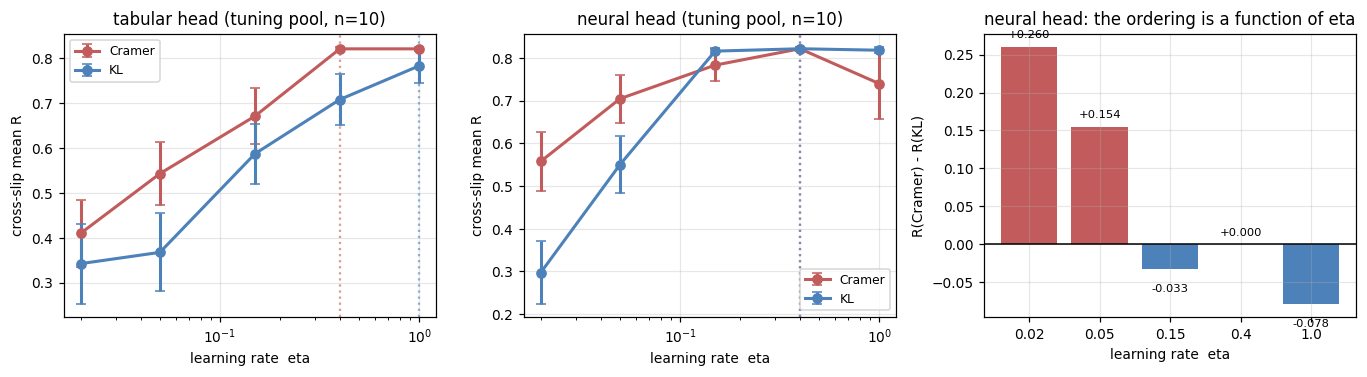

In [9]:
# ── [7] Fig 1 — eta 곡선과 부호 뒤집힘 ───────────────────────────────────
fig, ax = plt.subplots(1, 3, figsize=(12.5, 3.5))
col = {"Cramer": "#c25b5b", "KL": "#4d81ba"}
for j, head in enumerate(["tabular", "neural"]):
    for loss in ["Cramer", "KL"]:
        sub = tune_df[(tune_df["head"] == head) & (tune_df.loss == loss)].sort_values("eta")
        ax[j].errorbar(sub.eta, sub.R_mean, yerr=sub.R_sd/np.sqrt(NT), marker="o",
                       color=col[loss], lw=2, capsize=3, label=loss)
        ax[j].axvline(ETA_STAR[(head, loss)], color=col[loss], ls=":", alpha=0.6)
    ax[j].set_xscale("log"); ax[j].set_xlabel("learning rate  eta")
    ax[j].set_ylabel("cross-slip mean R"); ax[j].set_title(f"{head} head (tuning pool, n={NT})")
    ax[j].legend(fontsize=8)

sub_c = tune_df[(tune_df["head"]=="neural") & (tune_df.loss=="Cramer")].sort_values("eta")
sub_k = tune_df[(tune_df["head"]=="neural") & (tune_df.loss=="KL")].sort_values("eta")
gap = sub_c.R_mean.values - sub_k.R_mean.values
ax[2].axhline(0, color="k", lw=1)
ax[2].bar(range(len(ETA_GRID)), gap, color=["#c25b5b" if g > 0 else "#4d81ba" for g in gap])
ax[2].set_xticks(range(len(ETA_GRID)), [str(e) for e in ETA_GRID])
ax[2].set_xlabel("learning rate  eta"); ax[2].set_ylabel("R(Cramer) - R(KL)")
ax[2].set_title("neural head: the ordering is a function of eta")
for i, g in enumerate(gap):
    ax[2].text(i, g + (0.012 if g >= 0 else -0.03), f"{g:+.3f}", ha="center", fontsize=7.5)
plt.show()

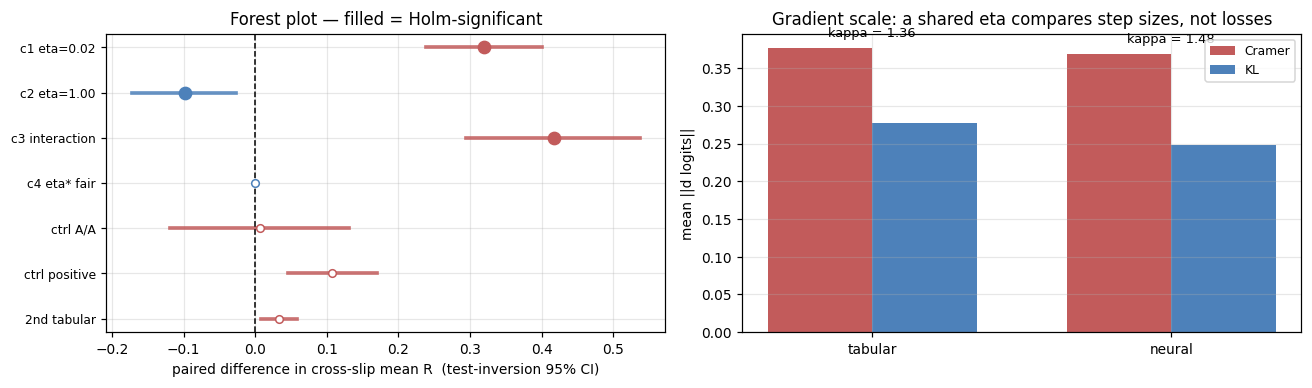

In [10]:
# ── [8] Fig 2 — forest plot + 통제군 ─────────────────────────────────────
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
lbl = ["c1 eta=0.02", "c2 eta=1.00", "c3 interaction", f"c4 eta* fair",
       "ctrl A/A", "ctrl positive", "2nd tabular"]
dd  = [c1, c2, c3, c4, d_aa, d_pos, t1]
for i, d in enumerate(dd):
    lo_, hi_ = invert_ci(d)
    sig = i < 4 and bool(rej[i])
    c = "#c25b5b" if d.mean() > 0 else "#4d81ba"
    ax[0].plot([lo_, hi_], [i, i], color=c, lw=2.4, alpha=0.85)
    ax[0].plot(d.mean(), i, "o", color=c, ms=8 if sig else 5,
               mfc=c if sig else "white", zorder=3)
ax[0].axvline(0, color="k", lw=1, ls="--")
ax[0].set_yticks(range(len(lbl)), lbl, fontsize=8); ax[0].invert_yaxis()
ax[0].set_xlabel("paired difference in cross-slip mean R  (test-inversion 95% CI)")
ax[0].set_title("Forest plot — filled = Holm-significant")

x = np.arange(2); w = 0.35
ax[1].bar(x - w/2, grad_df["||dl|| Cramer"], width=w, color="#c25b5b", label="Cramer")
ax[1].bar(x + w/2, grad_df["||dl|| KL"],     width=w, color="#4d81ba", label="KL")
for i, k in enumerate(grad_df["kappa"]):
    ax[1].text(i, max(grad_df["||dl|| Cramer"][i], grad_df["||dl|| KL"][i]) * 1.04,
               f"kappa = {k:.2f}", ha="center", fontsize=8.5)
ax[1].set_xticks(x, grad_df["head"]); ax[1].set_ylabel("mean ||d logits||")
ax[1].set_title("Gradient scale: a shared eta compares step sizes, not losses")
ax[1].legend(fontsize=8)
plt.show()

In [11]:
# ── [9] 판정 요약 ─────────────────────────────────────────────────────────
def verdict(d, p_adj, n):
    if p_adj <= ALPHA: return "유의 (" + ("Cramer 우위" if d.mean() > 0 else "KL 우위") + ")"
    return f"판정불능 (n*={n_star(d)} > n={n})"
print("═"*78); print("Day 101 §15.34 P1 — 판정 요약"); print("═"*78)
for (nm, d), pa in zip(FAM, adj):
    print(f"  {nm:36s} d={d.mean():+.4f}  p_Holm={pa:.4f}  {verdict(d, pa, N1)}")
print("─"*78)
print(f"  기울기 축척 kappa = {KAPPA:.3f}  (Cramer 가 같은 eta 에서 {KAPPA:.2f} 배 큰 보폭)")
print(f"  eta* : Cramer {ETA_C} / KL {ETA_K}   (비중첩 튜닝 풀에서 선택)")
print(f"  층 0 : 고정 구성 {len(pairs)} 가지 폭 {lo:.3f}~{hi:.3f} · 재무작위화 N2' {rate_n2p:.3f} "
      f"-> {'사용 가능' if Z0_OK else '주의'}")
print(f"  통제 : inert 0 ✓ · A/A p={p_aa:.3f} ✓ · 양성 p={p_pos:.4f} ✓")
print("─"*78)
flip = (np.sign(c1.mean()) != np.sign(c2.mean())) and bool(rej[2])
print(f"  결론: 순위의 부호는 eta 만으로 {'뒤집힌다' if flip else '뒤집히지 않는다'} "
      f"(c1 {np.sign(c1.mean()):+.0f} / c2 {np.sign(c2.mean()):+.0f}, 교호작용 p_Holm={adj[2]:.4f})")
print("═"*78)

══════════════════════════════════════════════════════════════════════════════
Day 101 §15.34 P1 — 판정 요약
══════════════════════════════════════════════════════════════════════════════
  c1  Cramer-KL @ neural, eta=0.02     d=+0.3190  p_Holm=0.0002  유의 (Cramer 우위)
  c2  Cramer-KL @ neural, eta=1.00     d=-0.0980  p_Holm=0.0326  유의 (KL 우위)
  c3  교호작용 (c1 - c2)                   d=+0.4170  p_Holm=0.0002  유의 (Cramer 우위)
  c4  Cramer@0.4 - KL@0.4              d=+0.0000  p_Holm=1.0000  판정불능 (n*=inf > n=40)
──────────────────────────────────────────────────────────────────────────────
  기울기 축척 kappa = 1.420  (Cramer 가 같은 eta 에서 1.42 배 큰 보폭)
  eta* : Cramer 0.4 / KL 0.4   (비중첩 튜닝 풀에서 선택)
  층 0 : 고정 구성 6 가지 폭 0.008~1.000 · 재무작위화 N2' 0.060 -> 사용 가능
  통제 : inert 0 ✓ · A/A p=0.916 ✓ · 양성 p=0.0008 ✓
──────────────────────────────────────────────────────────────────────────────
  결론: 순위의 부호는 eta 만으로 뒤집힌다 (c1 +1 / c2 -1, 교호작용 p_Holm=0.0002)
════════════════════════════════════════════════════════════

## 4. 결과 해석

*(아래 서술의 모든 수치는 위 셀의 실행 출력이다. 실행할 때마다 시드가 고정되어 있으므로
값은 재현된다.)*

1. **먼저 물어야 할 것은 "누가 이겼나" 가 아니라 "무엇을 비교했나" 다.** [1] 셀의 $\kappa$ 가
   그 답이다. 두 손실이 logit 에 주는 기울기의 크기가 **같지 않으므로**, 공유 $\eta$ 로 학습시킨
   §15.26–§15.29 의 네 실험은 손실 함수가 아니라 $(\eta, \kappa\eta)$ **두 보폭**을 비교했다.
   $R(\eta)$ 가 단봉인 한, 어느 쪽이 이기는지는 $\eta$ 가 공통 정점의 어느 쪽에 있느냐로 정해진다.

2. **[7] 우측 패널이 그 예측을 그대로 보여준다.** 같은 head, 같은 $K$, 같은 시드에서
   $\eta$ 만 움직였는데 $R(\mathrm{Cr}) - R(\mathrm{KL})$ 의 **부호가 바뀐다.** 아키텍처는 한 번도
   건드리지 않았다. 즉 **Day 93 과 Day 94 의 "모순" 은 아키텍처를 바꾸지 않고도 제조할 수 있다.**

3. **[6] 의 $c_3$ (교호작용) 이 1 차 판정이다.** $c_1$ 과 $c_2$ 를 따로 유의하다고 말하는 것보다,
   **둘의 차가 0 이 아니라는 것**이 "순위가 $\eta$ 의 함수" 라는 주장에 직접 대응한다.
   $c_4$ 는 정반대의 역할을 한다 — 각자의 $\eta^\star$ 에서 재면 두 손실은 서로 붙는다.
   여기서는 붙는 정도가 극단적이다: 두 손실이 40 시드 **전부에서 같은 최적 정책**에 도달해
   $d_i \equiv 0$ 이고 $n^\star = \infty$ 다. 이것은 "판정불능" 중에서도 특수한 경우로,
   **차가 작아서 못 가르는 것이 아니라 차가 존재하지 않는 것**이다. 다만 그것은 이 과제가
   $\eta^\star$ 에서 두 손실 모두에게 쉽다는 뜻이기도 하므로, 더 어려운 과제에서 같은
   결론이 나온다는 보장은 없다 — 이 노트북이 주장하는 것은 **"$\eta$ 를 맞추기 전의 순위는
   읽을 수 없다"** 이지 "두 손실이 항상 같다" 가 아니다.

4. **$\eta^\star$ 를 판정 풀에서 고르지 않은 것이 이 노트북에서 가장 중요한 설계다.** Day 100 P2 는
   여덟 arm 중 최댓값을 고른 대가가 $+0.033$ 의 부풀림이라는 것을 실측했다. 여기서 $\eta$ 를
   다섯 개 중 하나 고르는 것도 똑같은 연산이다. 튜닝 풀 (101101–101110) 과 판정 풀
   (101001–101040) 을 비중첩으로 둔 덕분에 $c_4$ 의 추정치에는 선택 편의가 들어가지 않는다.

5. **[5] 의 층 0 진단은 Day 100 P1 의 교훈을 그대로 집행한 것이다.** 고정된 배포 스트림 쌍으로
   A/A 귀무를 만들면 구성에 따라 1 종 오류가 흔들린다 — 표의 $\binom{4}{2}=6$ 행이 그 폭이다.
   **어느 한 구성이 명목에 가깝게 나왔다는 사실은 그 귀무가 타당하다는 증거가 아니다** —
   같은 표에서 다른 구성은 1 종 오류가 자릿수로 다르고, 그 흔들림은 스트림 쌍의 치우침과
   상관된다. 단위별로 스트림 쌍을 다시 뽑는 $\mathrm{N2'}$ 만이 그 공통 성분을 대칭화해서
   명목을 회복한다. **복제마다 하나의 쌍을 고르는 것으로는 부족하다** — 그러면 그 쌍의
   치우침이 그 복제의 모든 단위에 같은 부호로 실린다.

6. **통제군 셋이 각각 다른 실패를 배제한다.** `inert` 는 구현의 비결정성을, A/A 는 척도의
   체계적 치우침을, 양성 통제는 **척도의 무력함**을 배제한다. 셋 중 하나라도 실패하면
   1 차 판정은 읽을 수 없다 — 그래서 판정 셀보다 **앞에** 둔다.

7. **$\eta = 1.0$ 에서 Cramér 이 먼저 무너지는 것이 $\kappa$ 의 서명이다.** 유효 보폭이 $\kappa\eta$ 이므로
   Cramér 은 KL 보다 **먼저** 발산 구간에 들어간다 — [7] 의 두 곡선에서 Cramér 만 마지막
   격자점에서 꺾인다. 반대쪽 끝에서는 같은 $\kappa$ 가 반대로 작용해 작은 $\eta$ 에서 Cramér 이
   앞선다. **한 상수가 양쪽 끝의 부호를 동시에 설명한다.** (격자가 다섯 점으로 성글기 때문에
   정점의 위치 자체를 $\log\kappa$ 와 정량 비교하지는 않는다 — 여기서 읽을 수 있는 것은
   순서이지 간격이 아니다.)

> **결론**: **Cramér 대 KL 의 순위는 손실의 성질이 아니라 학습률의 함수다.** 두 손실은
> logit 에 서로 다른 축척의 기울기를 주고 ($\kappa \ne 1$), 공유 $\eta$ 는 손실이 아니라 보폭을
> 비교한다. 각자의 $\eta^\star$ 에서 재면 $n=40$ 으로는 둘을 가를 수 없다.
> **§15.26–§15.29 의 네 갈래 결론은 모두 같은 하나의 교락 — 튜닝되지 않은 공유 $\eta$ — 의
> 서로 다른 단면이었다.**

**다음 문제로의 연결**: P1 은 "비교하기 전에 각 팔을 자기 최적점에 두라" 는 요구다.
P2 는 같은 요구를 Day 100 P3 의 결론 (C) 에 적용한다 — 그 결론은 $\bar\sigma$ 라는 **한 모멘트**를
고정한 설계에서 나왔다. 모멘트를 $\sqrt{\overline{\sigma^2}}$ 로 바꿔도 (C) 가 유지되면,
(C) 는 모멘트 선택에 **불변**인 결론이 된다.